# Error analysis and experiment summary

This notebook consolidates the final experiment results and examines where the main trade-offs came from.

It covers:

- a single table of held-out test metrics
- normalization ablation comparison
- final-model error analysis
- per-view behaviour for the final model
- best / median / worst examples for the final ResUNet

In [1]:
from pathlib import Path
import json
import sys
import yaml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

ROOT = Path("..").resolve()
if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))

from mri_translation.data.datasets import build_dataset_bundle
from mri_translation.engine.evaluate import load_checkpoint
from mri_translation.engine.train import resolve_device
from mri_translation.models.factory import build_model

DEVICE = resolve_device("auto")
plt.rcParams["image.cmap"] = "gray"
plt.rcParams["figure.figsize"] = (8, 5)

/home/dreadgator/mri-modality-translation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RUN_TABLE = [
    {
        "run_name": "baseline_encoder_decoder_global_minmax",
        "label": "Baseline encoder-decoder",
        "normalization": "global min-max",
        "model_name": "baseline_encoder_decoder",
        "config": ROOT / "configs" / "baseline_encoder_decoder_global_minmax.yaml",
        "run_dir": ROOT / "outputs" / "runs" / "baseline_encoder_decoder_global_minmax",
    },
    {
        "run_name": "unet_global_minmax",
        "label": "U-Net",
        "normalization": "global min-max",
        "model_name": "unet",
        "config": ROOT / "configs" / "unet_global_minmax.yaml",
        "run_dir": ROOT / "outputs" / "runs" / "unet_global_minmax",
    },
    {
        "run_name": "baseline_encoder_decoder_percentile_minmax",
        "label": "Baseline encoder-decoder",
        "normalization": "percentile min-max",
        "model_name": "baseline_encoder_decoder",
        "config": ROOT / "configs" / "baseline_encoder_decoder_percentile_minmax.yaml",
        "run_dir": ROOT / "outputs" / "runs" / "baseline_encoder_decoder_percentile_minmax",
    },
    {
        "run_name": "unet_percentile_minmax",
        "label": "U-Net",
        "normalization": "percentile min-max",
        "model_name": "unet",
        "config": ROOT / "configs" / "unet_percentile_minmax.yaml",
        "run_dir": ROOT / "outputs" / "runs" / "unet_percentile_minmax",
    },
    {
        "run_name": "resunet_global_minmax",
        "label": "ResUNet",
        "normalization": "global min-max",
        "model_name": "resunet",
        "config": ROOT / "configs" / "resunet_global_minmax.yaml",
        "run_dir": ROOT / "outputs" / "runs" / "resunet_global_minmax",
    },
]

In [3]:
rows = []
for spec in RUN_TABLE:
    metrics_path = spec["run_dir"] / "metrics_test.json"
    with open(metrics_path, "r", encoding="utf-8") as f:
        metrics = json.load(f)

    rows.append(
        {
            "run_name": spec["run_name"],
            "label": spec["label"],
            "normalization": spec["normalization"],
            "mse": metrics["mse"],
            "mae": metrics["mae"],
            "rmse": metrics["rmse"],
            "psnr": metrics["psnr"],
            "ssim": metrics["ssim"],
        }
    )

results_df = pd.DataFrame(rows)
results_df

,run_name,label,normalization,mse,mae,rmse,psnr,ssim
0,baseline_encoder_decoder_global_minmax,Baseline encoder-decoder,global min-max,0.000667,0.005515,0.025826,45.397763,0.928267
1,unet_global_minmax,U-Net,global min-max,0.000372,0.007243,0.019291,43.164034,0.855920
2,baseline_encoder_decoder_percentile_minmax,Baseline encoder-decoder,percentile min-max,0.001744,0.012532,0.041756,35.736938,0.801112
3,unet_percentile_minmax,U-Net,percentile min-max,0.001580,0.025495,0.039747,31.786739,0.363207
4,resunet_global_minmax,ResUNet,global min-max,0.000580,0.006481,0.024082,43.969058,0.902884


In [4]:
print(results_df.to_markdown(index=False))
results_df

tables_dir = ROOT / "reports" / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

results_df.to_csv(tables_dir / "test_results_table.csv", index=False)
(tables_dir / "test_results_table.md").write_text(results_df.to_markdown(index=False), encoding="utf-8")
print("Saved test results table to", tables_dir)

| run_name                                   | label                    | normalization      |         mse |        mae |      rmse |    psnr |     ssim |
|:-------------------------------------------|:-------------------------|:-------------------|------------:|-----------:|----------:|--------:|---------:|
| baseline_encoder_decoder_global_minmax     | Baseline encoder-decoder | global min-max     | 0.000666983 | 0.00551545 | 0.025826  | 45.3978 | 0.928267 |
| unet_global_minmax                         | U-Net                    | global min-max     | 0.000372128 | 0.00724286 | 0.0192906 | 43.164  | 0.85592  |
| baseline_encoder_decoder_percentile_minmax | Baseline encoder-decoder | percentile min-max | 0.00174357  | 0.0125319  | 0.0417561 | 35.7369 | 0.801112 |
| unet_percentile_minmax                     | U-Net                    | percentile min-max | 0.0015798   | 0.025495   | 0.0397467 | 31.7867 | 0.363207 |
| resunet_global_minmax                      | ResUNet                

## What the main results table already tells us

Two things are immediately clear from the held-out test results:

1. **Global min-max** is the stronger preprocessing choice.
2. The final model choice cannot be made from a single metric alone.

For example, the U-Net achieved the strongest MSE / RMSE values among the pre-ResUNet models, but qualitative inspection still showed meaningful background artifacts. That gap between quantitative and qualitative evaluation is one of the main reasons this repository keeps both.

## Normalization ablation summary

The normalization ablation is easier to interpret when grouped by architecture.

In [5]:
ablation_df = results_df.pivot(index="label", columns="normalization", values=["mse", "mae", "rmse", "psnr", "ssim"])
ablation_df

mse                               mae  \
normalization            global min-max percentile min-max global min-max   
label                                                                       
Baseline encoder-decoder       0.000667           0.001744       0.005515   
ResUNet                        0.000580                NaN       0.006481   
U-Net                          0.000372           0.001580       0.007243   

                                                      rmse                     \
normalization            percentile min-max global min-max percentile min-max   
label                                                                           
Baseline encoder-decoder           0.012532       0.025826           0.041756   
ResUNet                                 NaN       0.024082                NaN   
U-Net                              0.025495       0.019291           0.039747   

                                   psnr                              ssim  \
normalization            global min-max percentile min-max global min-max   
label                                                                       
Baseline encoder-decoder      45.397763          35.736938       0.928267   
ResUNet                       43.969058                NaN       0.902884   
U-Net                         43.164034          31.786739       0.855920   

                                             
normalization            percentile min-max  
label                                        
Baseline encoder-decoder           0.801112  
ResUNet                                 NaN  
U-Net                              0.363207

In [6]:
global_df = results_df[results_df["normalization"] == "global min-max"].set_index("label")
pct_df = results_df[results_df["normalization"] == "percentile min-max"].set_index("label")

common_labels = sorted(set(global_df.index) & set(pct_df.index))

delta_rows = []
for label in common_labels:
    delta_rows.append(
        {
            "label": label,
            "delta_mse_pct_minus_global": pct_df.loc[label, "mse"] - global_df.loc[label, "mse"],
            "delta_rmse_pct_minus_global": pct_df.loc[label, "rmse"] - global_df.loc[label, "rmse"],
            "delta_psnr_pct_minus_global": pct_df.loc[label, "psnr"] - global_df.loc[label, "psnr"],
            "delta_ssim_pct_minus_global": pct_df.loc[label, "ssim"] - global_df.loc[label, "ssim"],
        }
    )

delta_df = pd.DataFrame(delta_rows)
delta_df

,label,delta_mse_pct_minus_global,delta_rmse_pct_minus_global,delta_psnr_pct_minus_global,delta_ssim_pct_minus_global
0,Baseline encoder-decoder,0.001077,0.015930,-9.660825,-0.127155
1,U-Net,0.001208,0.020456,-11.377295,-0.492712


In [7]:
delta_df.to_csv(tables_dir / "normalization_ablation_deltas.csv", index=False)
(tables_dir / "normalization_ablation_deltas.md").write_text(
    delta_df.to_markdown(index=False), encoding="utf-8"
)
print("Saved normalization delta table to", tables_dir)

Saved normalization delta table to /home/dreadgator/mri-modality-translation/reports/tables


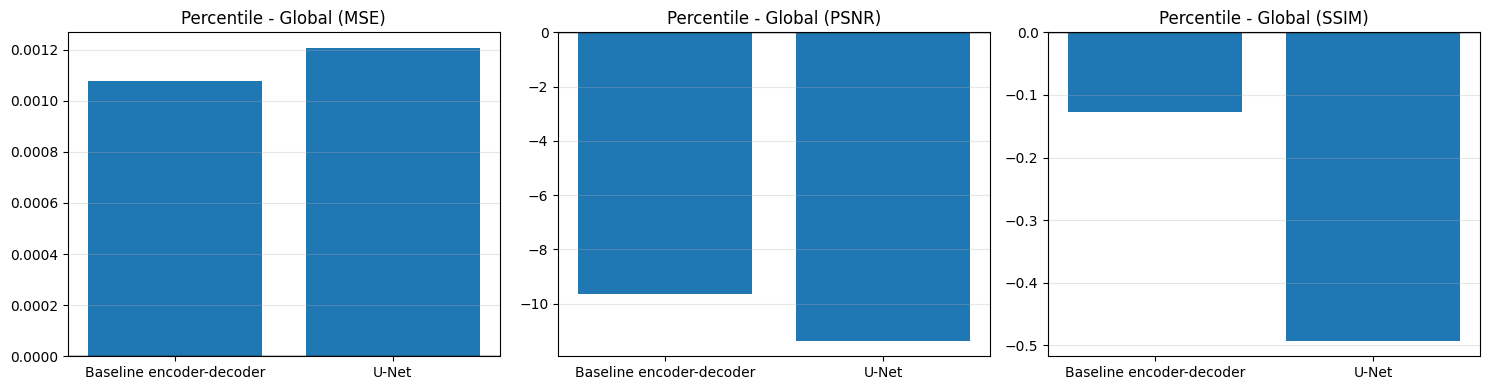

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(delta_df["label"], delta_df["delta_mse_pct_minus_global"])
axes[0].axhline(0.0, color="black", linewidth=1)
axes[0].set_title("Percentile - Global (MSE)")
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar(delta_df["label"], delta_df["delta_psnr_pct_minus_global"])
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].set_title("Percentile - Global (PSNR)")
axes[1].grid(True, axis="y", alpha=0.3)

axes[2].bar(delta_df["label"], delta_df["delta_ssim_pct_minus_global"])
axes[2].axhline(0.0, color="black", linewidth=1)
axes[2].set_title("Percentile - Global (SSIM)")
axes[2].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
save_path = ROOT / "reports" / "figures" / "normalization_ablation_deltas.png"
save_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_path, dpi=200, bbox_inches="tight")
print("Saved:", save_path)

Saved: /home/dreadgator/mri-modality-translation/reports/figures/normalization_ablation_deltas.png


### Normalization ablation interpretation

The percentile-minmax runs were not just “different”; they were decisively worse overall on the held-out test split.

That makes the normalization ablation useful in two ways:

- it shows that skewed raw intensity distributions were worth investigating
- it also shows that a plausible-looking preprocessing change can still degrade the actual held-out results

In the final repository narrative, percentile min-max is therefore retained as a **useful failed ablation**, not as a discarded side experiment.

## Final-model error analysis

The next cells analyse the final `resunet_global_minmax` checkpoint on the held-out test split.

This is the only notebook section that performs a full test-set forward pass, because it is needed to compute per-sample error rankings.

In [10]:
def load_yaml(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)

from copy import deepcopy

resunet_cfg = load_yaml(ROOT / "configs" / "resunet_global_minmax.yaml")
resunet_data_cfg = deepcopy(resunet_cfg["data"])
resunet_data_cfg["local_dataset_dir"] = str((ROOT / resunet_data_cfg["local_dataset_dir"]).resolve())
resunet_data_cfg["cache_dir"] = str((ROOT / resunet_data_cfg["cache_dir"]).resolve())
resunet_data_cfg["split"]["split_dir"] = str((ROOT / resunet_data_cfg["split"]["split_dir"]).resolve())

resunet_bundle = build_dataset_bundle(resunet_data_cfg)

resunet_loader = DataLoader(
    resunet_bundle.test,
    batch_size=resunet_cfg["loader"]["batch_size"],
    shuffle=False,
    num_workers=resunet_cfg["loader"]["num_workers"],
    pin_memory=resunet_cfg["loader"]["pin_memory"],
)

resunet_model = build_model("resunet").to(DEVICE)
load_checkpoint(resunet_model, ROOT / "outputs" / "runs" / "resunet_global_minmax" / "best.pt", DEVICE)
resunet_model.eval()

print("Test samples:", len(resunet_bundle.test))

Test samples: 24570


In [11]:
rows = []
running_idx = 0

with torch.no_grad():
    for batch in resunet_loader:
        x = batch["input"].to(DEVICE)
        y = batch["target"].cpu()
        pred = torch.clamp(resunet_model(x), 0.0, 1.0).cpu()

        mse = ((pred - y) ** 2).flatten(1).mean(dim=1).numpy()
        mae = (pred - y).abs().flatten(1).mean(dim=1).numpy()
        views = batch["view"]

        batch_size = len(views)
        for local_idx in range(batch_size):
            rows.append(
                {
                    "dataset_position": running_idx + local_idx,
                    "view": views[local_idx],
                    "mse": float(mse[local_idx]),
                    "mae": float(mae[local_idx]),
                }
            )
        running_idx += batch_size

resunet_error_df = pd.DataFrame(rows)
resunet_error_df.head()

,dataset_position,view,mse,mae
0,0,axial,0.000029,0.003486
1,1,axial,0.000028,0.003438
2,2,axial,0.000027,0.003410
3,3,axial,0.000026,0.003386
4,4,axial,0.000030,0.003470


In [12]:
resunet_error_df[["mse", "mae"]].describe()

,mse,mae
count,24570.000000,24570.000000
mean,0.000580,0.006475
std,0.003779,0.012304
min,0.000004,0.001740
25%,0.000017,0.003114
50%,0.000031,0.003950
75%,0.000058,0.005168
max,0.071646,0.159673


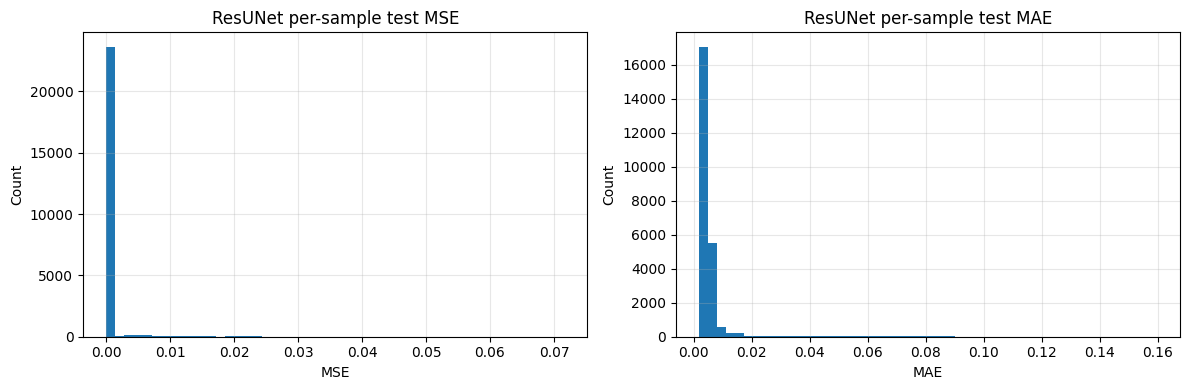

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(resunet_error_df["mse"], bins=50)
axes[0].set_title("ResUNet per-sample test MSE")
axes[0].set_xlabel("MSE")
axes[0].set_ylabel("Count")
axes[0].grid(True, alpha=0.3)

axes[1].hist(resunet_error_df["mae"], bins=50)
axes[1].set_title("ResUNet per-sample test MAE")
axes[1].set_xlabel("MAE")
axes[1].set_ylabel("Count")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
save_path = ROOT / "reports" / "figures" / "resunet_error_distributions.png"
save_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_path, dpi=200, bbox_inches="tight")
print("Saved:", save_path)

Saved: /home/dreadgator/mri-modality-translation/reports/figures/resunet_error_distributions.png


In [15]:
per_view_df = resunet_error_df.groupby("view", as_index=False)[["mse", "mae"]].mean()
per_view_df

,view,mse,mae
0,axial,0.000597,0.006580
1,coronal,0.000723,0.006597
2,sagittal,0.000426,0.006288


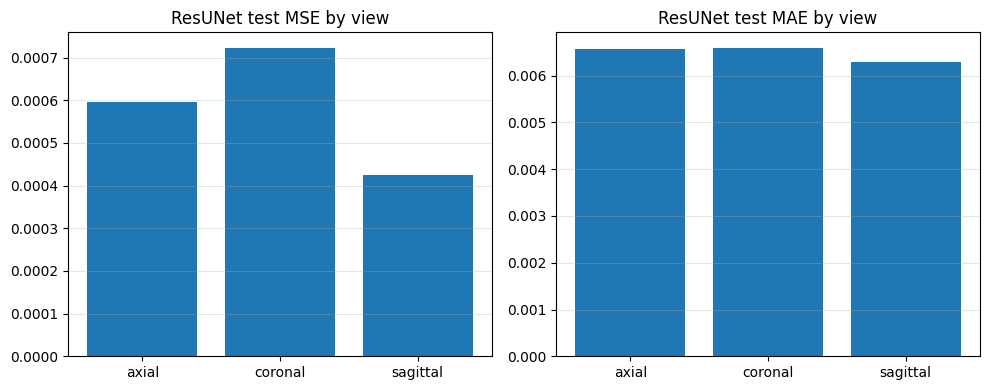

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(per_view_df["view"], per_view_df["mse"])
axes[0].set_title("ResUNet test MSE by view")
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar(per_view_df["view"], per_view_df["mae"])
axes[1].set_title("ResUNet test MAE by view")
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
per_view_df.to_csv(tables_dir / "resunet_per_view_metrics.csv", index=False)
(tables_dir / "resunet_per_view_metrics.md").write_text(
    per_view_df.to_markdown(index=False), encoding="utf-8"
)
print("Saved per-view metrics table to", tables_dir)

Saved per-view metrics table to /home/dreadgator/mri-modality-translation/reports/tables


In [18]:
save_path = ROOT / "reports" / "figures" / "resunet_per_view_metrics.png"
save_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_path, dpi=200, bbox_inches="tight")
print("Saved:", save_path)

Saved: /home/dreadgator/mri-modality-translation/reports/figures/resunet_per_view_metrics.png


### Per-view interpretation

The per-view breakdown is descriptive rather than definitive, but it is still useful for checking whether one anatomical orientation is substantially harder than the others for the final model.

If the differences are small, that is a good sign that the final model is not being carried by a single easier view.

## Best / median / worst examples

The examples below are selected from the final model using per-sample test MSE:

- lowest-error examples
- median examples
- highest-error examples

In [19]:
best_examples = resunet_error_df.nsmallest(2, "mse")
worst_examples = resunet_error_df.nlargest(2, "mse")

median_target = resunet_error_df["mse"].median()
resunet_error_df["median_gap"] = (resunet_error_df["mse"] - median_target).abs()
median_examples = resunet_error_df.nsmallest(2, "median_gap")

example_rows = pd.concat(
    [
        best_examples.assign(group="best"),
        median_examples.assign(group="median"),
        worst_examples.assign(group="worst"),
    ],
    ignore_index=True,
)

example_rows

,dataset_position,view,mse,mae,group,median_gap
0,12421,sagittal,0.000004,0.001798,best,NaN
1,12422,sagittal,0.000004,0.001822,best,NaN
2,6906,coronal,0.000031,0.003517,median,2.964953e-10
3,10477,sagittal,0.000031,0.003789,median,2.964953e-10
4,20097,coronal,0.071646,0.153914,worst,NaN
5,20106,coronal,0.071543,0.158257,worst,NaN


In [20]:
example_rows[["group", "dataset_position", "view", "mse", "mae"]]

,group,dataset_position,view,mse,mae
0,best,12421,sagittal,0.000004,0.001798
1,best,12422,sagittal,0.000004,0.001822
2,median,6906,coronal,0.000031,0.003517
3,median,10477,sagittal,0.000031,0.003789
4,worst,20097,coronal,0.071646,0.153914
5,worst,20106,coronal,0.071543,0.158257


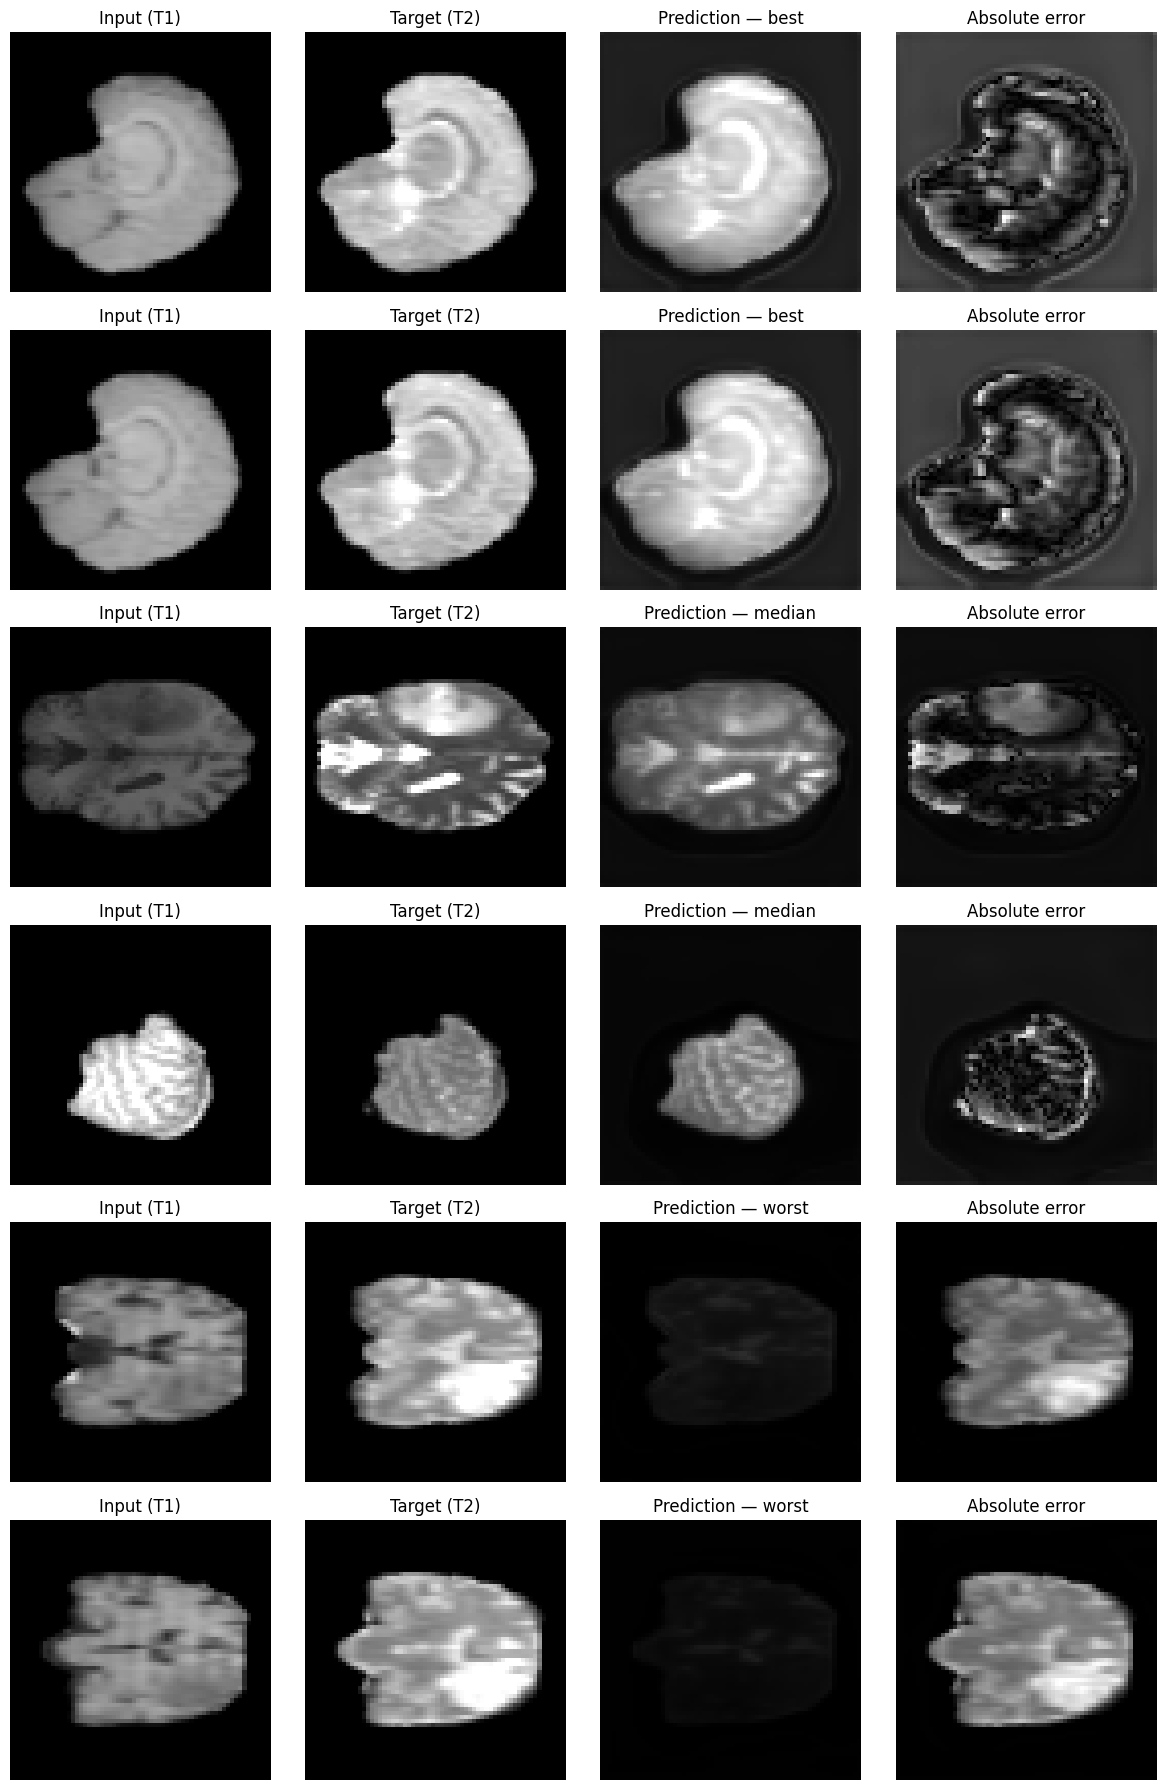

In [21]:
def robust_range(*arrays, lower=1.0, upper=99.0):
    stacked = np.concatenate([np.asarray(arr).reshape(-1) for arr in arrays])
    vmin = float(np.percentile(stacked, lower))
    vmax = float(np.percentile(stacked, upper))
    if vmax <= vmin:
        vmax = vmin + 1e-6
    return vmin, vmax

fig, axes = plt.subplots(len(example_rows), 4, figsize=(12, 3 * len(example_rows)))

with torch.no_grad():
    for row_idx, row in example_rows.reset_index(drop=True).iterrows():
        item = resunet_bundle.test[int(row["dataset_position"])]
        inp = item["input"].squeeze(0).numpy()
        tgt = item["target"].squeeze(0).numpy()

        x = item["input"].unsqueeze(0).to(DEVICE)
        pred = torch.clamp(resunet_model(x), 0.0, 1.0).cpu().squeeze(0).squeeze(0).numpy()
        abs_err = np.abs(pred - tgt)

        vmin, vmax = robust_range(inp, tgt, pred)

        axes[row_idx, 0].imshow(inp, vmin=vmin, vmax=vmax)
        axes[row_idx, 0].set_title("Input (T1)")
        axes[row_idx, 1].imshow(tgt, vmin=vmin, vmax=vmax)
        axes[row_idx, 1].set_title("Target (T2)")
        axes[row_idx, 2].imshow(pred, vmin=vmin, vmax=vmax)
        axes[row_idx, 2].set_title(f"Prediction — {row['group']}")
        axes[row_idx, 3].imshow(abs_err)
        axes[row_idx, 3].set_title("Absolute error")

        axes[row_idx, 0].set_ylabel(
            f"{row['group']} | {row['view']}\nMSE={row['mse']:.4e}",
            fontsize=10,
        )

        for ax in axes[row_idx]:
            ax.axis("off")

plt.tight_layout()
plt.show()

In [22]:
save_path = ROOT / "reports" / "figures" / "resunet_best_median_worst_panel.png"
save_path.parent.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(len(example_rows), 4, figsize=(12, 3 * len(example_rows)))

with torch.no_grad():
    for row_idx, row in example_rows.reset_index(drop=True).iterrows():
        item = resunet_bundle.test[int(row["dataset_position"])]
        inp = item["input"].squeeze(0).numpy()
        tgt = item["target"].squeeze(0).numpy()

        x = item["input"].unsqueeze(0).to(DEVICE)
        pred = torch.clamp(resunet_model(x), 0.0, 1.0).cpu().squeeze(0).squeeze(0).numpy()
        abs_err = np.abs(pred - tgt)

        vmin, vmax = robust_range(inp, tgt, pred)

        axes[row_idx, 0].imshow(inp, vmin=vmin, vmax=vmax)
        axes[row_idx, 0].set_title("Input (T1)")
        axes[row_idx, 1].imshow(tgt, vmin=vmin, vmax=vmax)
        axes[row_idx, 1].set_title("Target (T2)")
        axes[row_idx, 2].imshow(pred, vmin=vmin, vmax=vmax)
        axes[row_idx, 2].set_title(f"Prediction — {row['group']}")
        axes[row_idx, 3].imshow(abs_err)
        axes[row_idx, 3].set_title("Absolute error")

        axes[row_idx, 0].set_ylabel(
            f"{row['group']} | {row['view']}\nMSE={row['mse']:.4e}",
            fontsize=10,
        )

        for ax in axes[row_idx]:
            ax.axis("off")

plt.tight_layout()
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.close()

print("Saved:", save_path)

Saved: /home/dreadgator/mri-modality-translation/reports/figures/resunet_best_median_worst_panel.png


## Error-analysis summary

The final experiment set supports three main conclusions:

- **Global min-max** was the stronger preprocessing choice overall, while percentile min-max became a useful failed ablation.
- The simple encoder-decoder is a useful stability baseline, but is too blurry to serve as the final model.
- The final **ResUNet + global min-max** provides the strongest overall balance between held-out quantitative performance and qualitative behaviour.

The broader lesson from this project is that **quantitative and qualitative rankings did not align perfectly**. That is why the repository keeps both metric tables and qualitative panels rather than relying on a single summary metric.